In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
words = open('../hafta-4/names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

def build_dataset(words, block_size):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [3]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      # BatchNorm 3D hatası görev 4'te düzeltilecek, bu kod şimdiden doğru halini destekleyecek şekilde yazılmıştır
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0, 1)
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  def parameters(self):
    return [self.weight]

class Flatten:
  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out
  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

Bağlam 3 Modeli parametre sayısı: 6197


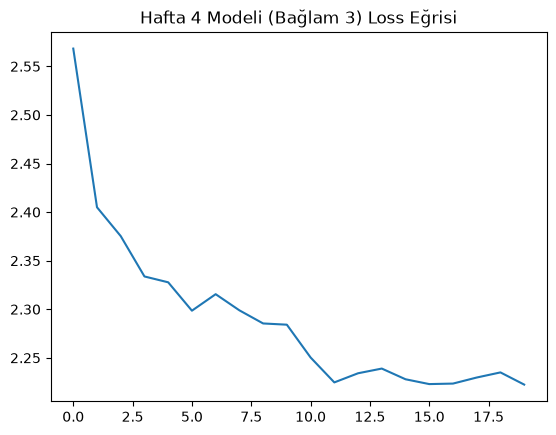

Train loss: 2.2039527893066406
Dev loss: 2.211944818496704


In [ ]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

block_size = 3
Xtr, Ytr = build_dataset(words[:n1], block_size)
Xdev, Ydev = build_dataset(words[n1:n2], block_size)
Xte, Yte = build_dataset(words[n2:], block_size)

n_embd = 10
n_hidden = 100

model = Sequential([
  Embedding(vocab_size, n_embd),
  Flatten(),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(f"Bağlam 3 Modeli parametre sayısı: {sum(p.nelement() for p in parameters)}")
for p in parameters:
  p.requires_grad = True

# max_steps'i bilerek düşük tutuyoruz ki notebook çok uzun süre çalışmasın, 
# Orijinalinde 200000 adımdı. Sınıfta genelde 10000-50000 arası da farkları görmek için yeterlidir.
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]
  
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)
  
  for p in parameters:
    p.grad = None
  loss.backward()
  
  lr = 0.1 if i < max_steps//2 else 0.01
  for p in parameters:
    p.data -= lr * p.grad
    
  lossi.append(loss.item())

# Loss Eğrisi çizimi - videodaki gibi tensör haline getirip ortalama alma yöntemi
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
plt.title("Hafta 4 Modeli (Bağlam 3) Loss Eğrisi")
plt.show()

for layer in model.layers:
  layer.training = False

@torch.no_grad()
def evaluate(model, X, Y):
  logits = model(X)
  loss = F.cross_entropy(logits, Y)
  return loss.item()

print("Train loss:", evaluate(model, Xtr, Ytr))
print("Dev loss:", evaluate(model, Xdev, Ydev))

In [5]:
block_size = 8
Xtr8, Ytr8 = build_dataset(words[:n1], block_size)
Xdev8, Ydev8 = build_dataset(words[n1:n2], block_size)

model8_flat = Sequential([
  Embedding(vocab_size, n_embd),
  Flatten(),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model8_flat.layers[-1].weight *= 0.1

parameters = model8_flat.parameters()
print(f"Bağlam 8 Düz MLP parametre sayısı: {sum(p.nelement() for p in parameters)}")
for p in parameters:
  p.requires_grad = True

for i in range(max_steps):
  ix = torch.randint(0, Xtr8.shape[0], (batch_size,))
  Xb, Yb = Xtr8[ix], Ytr8[ix]
  logits = model8_flat(Xb)
  loss = F.cross_entropy(logits, Yb)
  for p in parameters:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < max_steps//2 else 0.01
  for p in parameters:
    p.data -= lr * p.grad

for layer in model8_flat.layers:
  layer.training = False

print("Bağlam 8 Düz MLP Dev loss:", evaluate(model8_flat, Xdev8, Ydev8))

Bağlam 8 Düz MLP parametre sayısı: 11197
Bağlam 8 Düz MLP Dev loss: 2.1512463092803955


In [6]:
class FlattenConsecutive:
  def __init__(self, n):
    self.n = n
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  def parameters(self):
    return []

n_hidden = 68 # Parametre sayısını düz MLP ile yaklaşık aynı seviyede tutmak için

model_wavenet = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model_wavenet.layers[-1].weight *= 0.1

parameters = model_wavenet.parameters()
print(f"WaveNet parametre sayısı: {sum(p.nelement() for p in parameters)}")
for p in parameters:
  p.requires_grad = True

# Şekillerin (Shape) incelenmesi:
ix = torch.randint(0, Xtr8.shape[0], (4,))
Xb = Xtr8[ix]
print("Input shape:", Xb.shape)
x = Xb
for layer in model_wavenet.layers:
  x = layer(x)
  print(layer.__class__.__name__, ":", tuple(x.shape))

WaveNet parametre sayısı: 22397
Input shape: torch.Size([4, 8])
Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [7]:
for i in range(max_steps):
  ix = torch.randint(0, Xtr8.shape[0], (batch_size,))
  Xb, Yb = Xtr8[ix], Ytr8[ix]
  logits = model_wavenet(Xb)
  loss = F.cross_entropy(logits, Yb)
  for p in parameters:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < max_steps//2 else 0.01
  for p in parameters:
    p.data -= lr * p.grad

for layer in model_wavenet.layers:
  layer.training = False

print("WaveNet Dev loss:", evaluate(model_wavenet, Xdev8, Ydev8))

WaveNet Dev loss: 2.1112983226776123


In [8]:
n_embd = 24
n_hidden = 128 

model_wavenet_large = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model_wavenet_large.layers[-1].weight *= 0.1

parameters = model_wavenet_large.parameters()
print(f"Büyük WaveNet parametre sayısı: {sum(p.nelement() for p in parameters)}")
for p in parameters:
  p.requires_grad = True

for i in range(max_steps):
  ix = torch.randint(0, Xtr8.shape[0], (batch_size,))
  Xb, Yb = Xtr8[ix], Ytr8[ix]
  logits = model_wavenet_large(Xb)
  loss = F.cross_entropy(logits, Yb)
  for p in parameters:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < max_steps//2 else 0.01
  for p in parameters:
    p.data -= lr * p.grad

for layer in model_wavenet_large.layers:
  layer.training = False

print("Büyük WaveNet Dev loss:", evaluate(model_wavenet_large, Xdev8, Ydev8))

Büyük WaveNet parametre sayısı: 76579
Büyük WaveNet Dev loss: 2.055504322052002


In [ ]:
words_tr = open('../hafta-4/names_tr.txt', 'r').read().splitlines()
chars_tr = sorted(list(set(''.join(words_tr))))
stoi_tr = {s:i+1 for i,s in enumerate(chars_tr)}
stoi_tr['.'] = 0
itos_tr = {i:s for s,i in stoi_tr.items()}
vocab_size_tr = len(itos_tr)

def build_dataset_tr(words, block_size):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi_tr[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words_tr)
n1_tr = int(0.8*len(words_tr))
n2_tr = int(0.9*len(words_tr))

Xtr_tr, Ytr_tr = build_dataset_tr(words_tr[:n1_tr], 8)
Xdev_tr, Ydev_tr = build_dataset_tr(words_tr[n1_tr:n2_tr], 8)

model_wavenet_tr = Sequential([
  Embedding(vocab_size_tr, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size_tr),
])

with torch.no_grad():
  model_wavenet_tr.layers[-1].weight *= 0.1

parameters_tr = model_wavenet_tr.parameters()
for p in parameters_tr:
  p.requires_grad = True

for i in range(200000):

  ix = torch.randint(0, Xtr_tr.shape[0], (batch_size,))
  Xb, Yb = Xtr_tr[ix], Ytr_tr[ix]

  logits = model_wavenet_tr(Xb)

  loss = F.cross_entropy(logits, Yb)

  for p in parameters_tr:
    p.grad = None

  loss.backward()
  
  lr = 0.1 if i < max_steps//2 else 0.01
  for p in parameters_tr:
    p.data -= lr * p.grad

for layer in model_wavenet_tr.layers:
  layer.training = False

print("Türkçe WaveNet Dev loss:", evaluate(model_wavenet_tr, Xdev_tr, Ydev_tr))

print("\nÜretilen Türkçe İsimler:")
for _ in range(10):
    out = []
    context = [0] * 8
    while True:
        logits = model_wavenet_tr(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos_tr[i] for i in out[:-1]))

Türkçe WaveNet Dev loss: 3.792213201522827

Üretilen Türkçe İsimler:
zehra
sarper
figen
gulseren
nihal
aysun
ufuk
ecrin
veysel
tarkan
